In [4]:
# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)
import os


# Predict treatment response usign baseline immune infiltration

In [7]:
df = pd.read_csv("tismo_metadata_subset.csv")
cancer_list = ["Mammary carcinoma", "Mammary adenocarcinoma", "Mammary cancer, NOS"]
df_mammary = df[df["Cancer_type"].isin(cancer_list)]

df_ml = df_mammary[
    (df_mammary["Baseline"] == 1) &
    (df_mammary["ICB_Baseline_TYPE"].isin(["R","NR"]))
].copy()
# Obtain baseline samples with response labels

In [17]:
df_ml

,Study_ID,GSM_ID,IN_VIVO,Cancer_type,Cell_Line,sub_clone,Condition,ICB,B_quanTIseq,Dendritic_quanTIseq,...,Cell_genotype,Tumor,Mouse_genotype,Mouse_strain,Mouse_treatment,Timepoint,Implantation,Implantation_site,SRX_ID,SampleName
76,GSE107801,GSM2879407,in_vivo,Mammary carcinoma,EMT6,parental,NaN,0,0.027038,0.000000,...,WT,primary,WT,BALB/c,isotype,NaN,orthotopic,mammary fat pad,SRX3453162,SRX3453162
77,GSE107801,GSM2879408,in_vivo,Mammary carcinoma,EMT6,parental,NaN,0,0.015808,0.034340,...,WT,primary,WT,BALB/c,isotype,NaN,orthotopic,mammary fat pad,SRX3453163,SRX3453163
78,GSE107801,GSM2879409,in_vivo,Mammary carcinoma,EMT6,parental,NaN,0,0.007887,0.026494,...,WT,primary,WT,BALB/c,isotype,NaN,orthotopic,mammary fat pad,SRX3453164,SRX3453164
79,GSE107801,GSM2879410,in_vivo,Mammary carcinoma,EMT6,parental,NaN,0,0.008829,0.014672,...,WT,primary,WT,BALB/c,isotype,NaN,orthotopic,mammary fat pad,SRX3453165,SRX3453165
80,GSE107801,GSM2879411,in_vivo,Mammary carcinoma,EMT6,parental,NaN,0,0.007788,0.030937,...,WT,primary,WT,BALB/c,isotype,NaN,orthotopic,mammary fat pad,SRX3453166,SRX3453166
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1362,GSE174053,GSM5285283,in_vivo,Mammary adenocarcinoma,E0771,parental,high.fat.diet,0,0.008232,0.048710,...,luciferase,primary,WT,C57BL/6J,isotype; high.fat.diet;,NaN,orthotopic,mammary gland,SRX10815542,SRX10815542
1363,GSE174053,GSM5285284,in_vivo,Mammary adenocarcinoma,E0771,parental,high.fat.diet,0,0.016584,0.057639,...,luciferase,primary,WT,C57BL/6J,isotype; high.fat.diet;,NaN,orthotopic,mammary gland,SRX10815543,SRX10815543
1364,GSE174053,GSM5285285,in_vivo,Mammary adenocarcinoma,E0771,parental,high.fat.diet,0,0.015205,0.049033,...,luciferase,primary,WT,C57BL/6J,isotype; high.fat.diet;,NaN,orthotopic,mammary gland,SRX10815544,SRX10815544
1368,GSE174053,GSM5285289,in_vivo,Mammary adenocarcinoma,E0771,parental,high.fat.diet,0,0.026390,0.063830,...,luciferase,primary,WT,C57BL/6J,isotype; high.fat.diet;,NaN,orthotopic,mammary gland,SRX10815548,SRX10815548


In [18]:
print("ML dataset shape:", df_ml.shape)

ML dataset shape: (125, 33)


pd.crosstab(df["ICB_study"], df["Baseline"])

### Random Forest Implementation

In [19]:
# Cell 6

immune_features = [
    "B_quanTIseq",
    "Dendritic_quanTIseq",
    "Macrophage.M1_quanTIseq",
    "Macrophage.M2_quanTIseq",
    "Monocyte_quanTIseq",
    "Neutrophil_quanTIseq",
    "NK_quanTIseq",
    "T.CD4_quanTIseq",
    "T.CD8_quanTIseq",
    "Tregs_quanTIseq"
]

In [21]:
'''meta_features = [
    "Cell_Line",
    "Mouse_treatment",
    "Condition",
    "ICB_group"
]

features = immune_features + meta_features'''
# Late found that the model will predict the outcome based on meta labels. 
# so exclude these from the training. 

In [37]:
# Prepare feature matrix

X = df_ml[immune_features]
y = df_ml["ICB_Baseline_TYPE"]

X = pd.get_dummies(X)
X.head()

print("X shape:", X.shape)
print("y distribution:")
print(y.value_counts())

X shape: (125, 10)
y distribution:
ICB_Baseline_TYPE
R     69
NR    56
Name: count, dtype: int64


In [38]:
from sklearn.model_selection import GroupKFold

groups = df_ml["Cell_Line"]

gkf = GroupKFold(n_splits=5)

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

scores = []

for train_idx, test_idx in gkf.split(X, y, groups):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    score = accuracy_score(y_test, y_pred)
    scores.append(score)

print("Mean accuracy:", sum(scores)/len(scores))

Mean accuracy: 0.51052381245079


### Try improving the Random Forest Model Performance

In [40]:
X = df_ml[immune_features]
y = df_ml["ICB_Baseline_TYPE"]

print("X shape:", X.shape)
print("y distribution:")
print(y.value_counts())

X shape: (125, 10)
y distribution:
ICB_Baseline_TYPE
R     69
NR    56
Name: count, dtype: int64


In [41]:
# Drop rows missing immune features
X = X.dropna()

y = y.loc[X.index]

print("After cleaning:", X.shape)

After cleaning: (125, 10)


In [42]:
X = pd.get_dummies(X)
print("Encoded feature matrix shape:", X.shape)

Encoded feature matrix shape: (125, 10)


In [43]:
# Cell 11

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (100, 10)
Test size: (25, 10)


In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
scores = []

for train_idx, test_idx in gkf.split(X, y, groups):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    score = accuracy_score(y_test, y_pred)
    scores.append(score)

print("Mean accuracy:", sum(scores)/len(scores))

Mean accuracy: 0.51052381245079


In [ ]:
# Lower accuracy based on immune features alone

In [31]:
! pip install seaborn

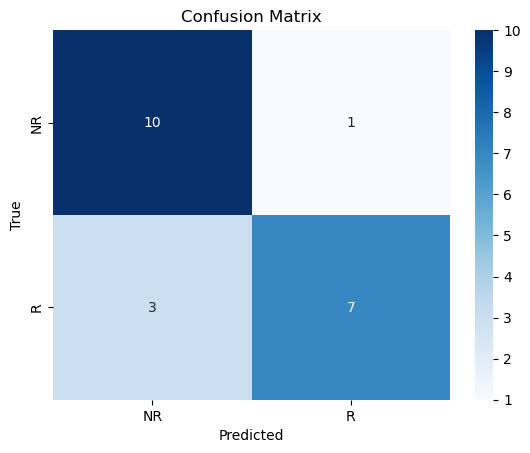

In [45]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NR","R"],
    yticklabels=["NR","R"]
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

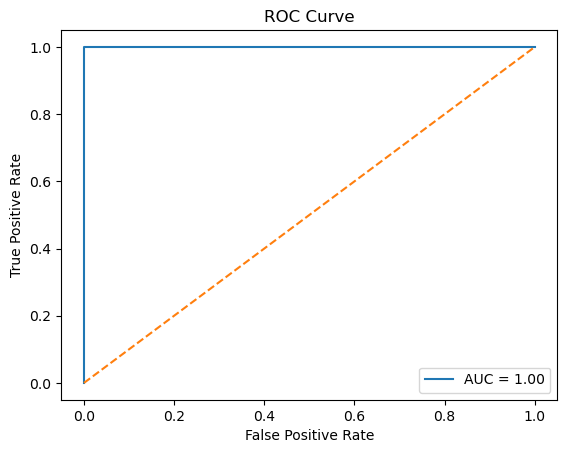

In [49]:
# Cell 15

y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob, pos_label="R")
roc_auc = auc(fpr, tpr)

plt.figure()

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()


# Comment, the oucome indicates leakage in model training

In [50]:
len(y_test)

21

In [51]:
pd.crosstab(df_ml["Cell_Line"], df_ml["ICB_Baseline_TYPE"])

ICB_Baseline_TYPE,NR,R
Cell_Line,,
4T1,10,7
E0771,8,0
EMT6,0,10
KPB25L,0,29
T11,13,23
p53-2225L,14,0
p53-2336R,11,0


### Grouping with stratified sampling, including both labels

In [52]:
# Prepare data
features = [
    "B_quanTIseq",
    "Dendritic_quanTIseq",
    "NK_quanTIseq",
    "T.CD8_quanTIseq",
    "Tregs_quanTIseq"
]

X = df_ml[features]
y = df_ml["ICB_Baseline_TYPE"]
groups = df_ml["Cell_Line"]

# convert labels
y = y.map({"NR":0, "R":1})

In [64]:
y

76      1
77      1
78      1
79      1
80      1
       ..
1362    0
1363    0
1364    0
1368    0
1369    0
Name: ICB_Baseline_TYPE, Length: 125, dtype: int64

In [53]:
# Group cross-validation
from sklearn.model_selection import GroupKFold

gkf = GroupKFold(n_splits=5)

In [59]:
# Random Forest training
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

auc_scores = []
all_y_test = []
all_y_prob = []
feature_importance = []

for train_idx, test_idx in gkf.split(X, y, groups):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Skip folds with only one class (include only ones with both R and NR)
    if len(np.unique(y_test)) < 2:
        print("Skipping fold (single class)")
        continue

    rf = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    )

    rf.fit(X_train, y_train)

    y_prob = rf.predict_proba(X_test)[:,1]

    auc = roc_auc_score(y_test, y_prob)
    auc_scores.append(auc)

    # Store predictions
    all_y_test.extend(y_test)
    all_y_prob.extend(y_prob)

    # Store feature importance
    feature_importance.append(rf.feature_importances_)

print("Mean AUC:", np.mean(auc_scores))

Skipping fold (single class)
Skipping fold (single class)
Mean AUC: 0.6325363042754346


Mean AUC = 0.6325363042754346

In [65]:
# Explore feature importance iwth built-in score  - ROC Curve (aggregaed across folds)
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(all_y_test, all_y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()

plt.show()


ValueError: y_true takes value in {} and pos_label is not specified: either make y_true take value in {0, 1} or {-1, 1} or pass pos_label explicitly.

In [ ]:
# Random Forest is not working well. 

# XGBoost modeling

In [36]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [67]:
df = pd.read_csv("tismo_metadata_subset.csv")
cancer_list = ["Mammary carcinoma", "Mammary adenocarcinoma", "Mammary cancer, NOS"]
df_mammary = df[df["Cancer_type"].isin(cancer_list)]

df_ml = df_mammary[
    (df_mammary["Baseline"] == 1) &
    (df_mammary["ICB_Baseline_TYPE"].isin(["R","NR"]))
].copy()
# Obtain baseline samples with response labels
print(df_ml.shape)
print(df_ml["ICB_Baseline_TYPE"].value_counts())

(125, 33)
ICB_Baseline_TYPE
R     69
NR    56
Name: count, dtype: int64


In [69]:
immune_features = [
"B_quanTIseq",
"Dendritic_quanTIseq",
"Macrophage.M1_quanTIseq",
"Macrophage.M2_quanTIseq",
"Monocyte_quanTIseq",
"Neutrophil_quanTIseq",
"NK_quanTIseq",
"T.CD4_quanTIseq",
"T.CD8_quanTIseq",
"Tregs_quanTIseq"
]

In [71]:
# Encode categorical variables
df_ml = pd.get_dummies(
    df_ml,
    columns=["Cell_Line","Mouse_treatment","ICB_group"]
)

In [81]:
df_ml["response"] = df_ml["ICB_Baseline_TYPE"].map({"NR":0, "R":1})

In [83]:
# define feature list - immune infiltration
features = [c for c in df_ml.columns if any(f in c for f in immune_features)]

In [86]:
# Drop NaN values
data = pd.concat([X, y], axis=1).dropna()

X = data[features]
y = data["response"]

In [88]:
print("NaN in y:", y.isna().sum())
print("Unique labels:", y.unique())

NaN in y: 0
Unique labels: [1 0]


In [90]:
# Check class balance based, because of small sample size
y.value_counts(normalize=True)

response
1    0.552
0    0.448
Name: proportion, dtype: float64

[1 0]


In [91]:
# Stratified cross-validation
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [93]:
# Train XGBoost
from xgboost import XGBClassifier

auc_scores = []

all_y_test = []
all_y_prob = []

feature_importances = []

for train_idx, test_idx in skf.split(X,y):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = XGBClassifier(
        n_estimators=500,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )

    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:,1]

    auc = roc_auc_score(y_test, y_prob)

    auc_scores.append(auc)

    all_y_test.extend(y_test)
    all_y_prob.extend(y_prob)

    feature_importances.append(model.feature_importances_)

/home/zhilin/miniforge3/envs/single_cell_analysis/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/zhilin/miniforge3/envs/single_cell_analysis/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


Mean accuracy: 0.5068
Mean AUC: nan


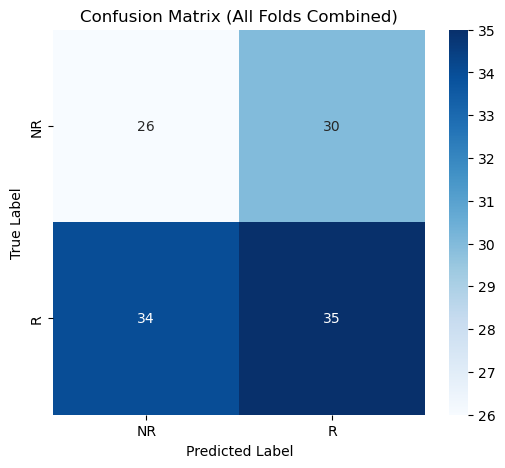

In [94]:
import numpy as np
import pandas as pd
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming gkf, X, y, and groups are already defined in your environment

scores = []
auc_scores = []

# Lists to hold all predictions and true labels across all folds
all_y_test = []
all_y_pred = []

# List to hold feature importance for each fold
fold_importance = []

for train_idx, test_idx in gkf.split(X, y, groups):
    # Split the data
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Initialize the model (Note: early_stopping_rounds is added here in newer XGBoost versions)
    model = XGBClassifier(
        n_estimators=500,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        early_stopping_rounds=20 # Stops training if logloss doesn't improve for 20 rounds
    )

    # Fit the model and pass the evaluation set
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False # Set to True if you want to see the loss drop per tree
    )

    # Predict classes and probabilities
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Calculate metrics for this specific fold
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    scores.append(acc)
    auc_scores.append(auc)

    # Accumulate predictions for the global confusion matrix
    all_y_test.extend(y_test)
    all_y_pred.extend(y_pred)

# Print overall cross-validation results
print(f"Mean accuracy: {np.mean(scores):.4f}")
print(f"Mean AUC: {np.mean(auc_scores):.4f}")

# Generate the global confusion matrix
cm = confusion_matrix(all_y_test, all_y_pred)

# Plotting
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NR", "R"],
    yticklabels=["NR", "R"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (All Folds Combined)")
plt.show()

In [32]:
# Calculate the average importance across all folds
mean_importances = np.mean(fold_importances, axis=0)

# Create a DataFrame to link feature names to their average importance scores
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': mean_importances
})

# Sort the features from most important to least important
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot the results
plt.figure(figsize=(10, 8))
sns.barplot(
    data=importance_df, 
    x='Importance', 
    y='Feature', 
    palette='viridis' # A nice color scheme for charts
)

plt.title('Average Feature Importances Across All Folds')
plt.xlabel('Importance Score (Gain)')
plt.ylabel('Feature')
plt.tight_layout() # Ensures labels don't get cut off
plt.show()

NameError: name 'fold_importances' is not defined

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


Mean accuracy: 0.4705
Mean AUC: 0.5394


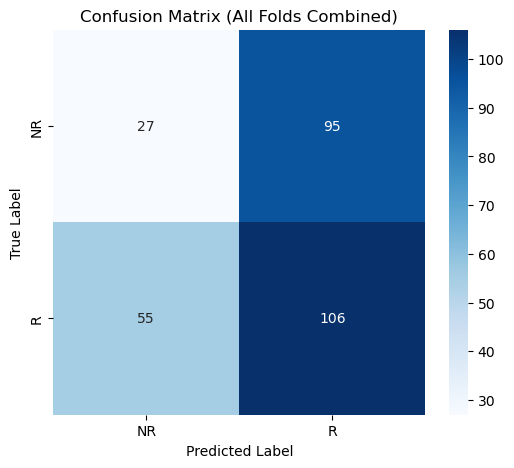

/tmp/ipykernel_5301/1826494220.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


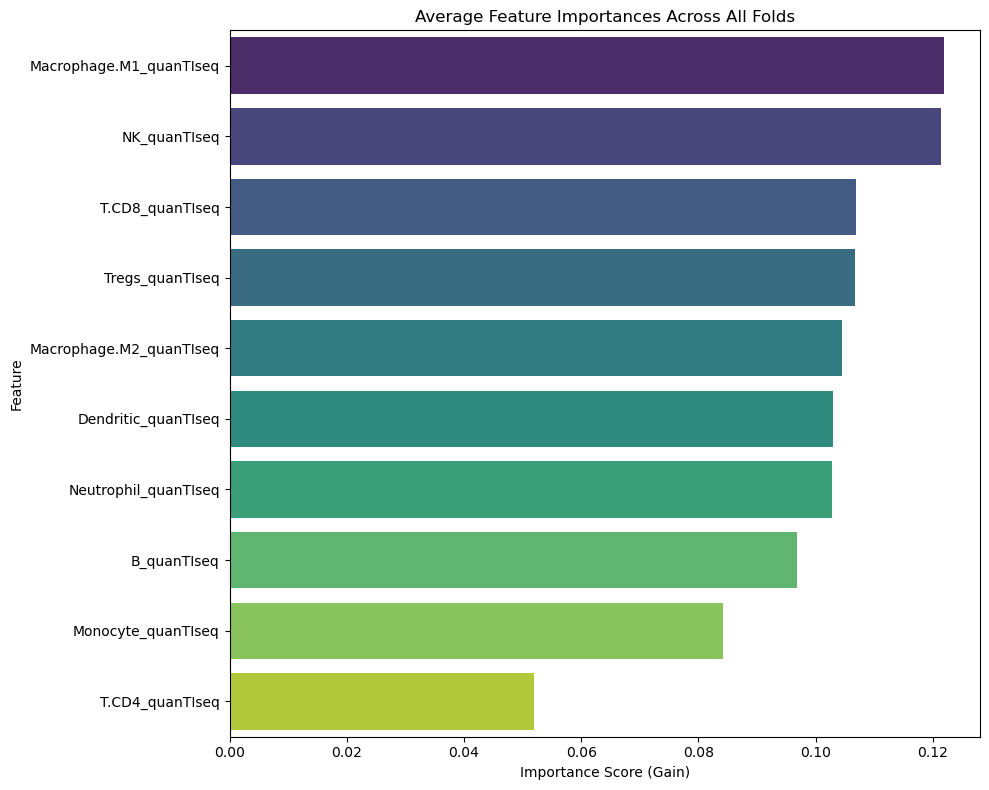

In [33]:
import numpy as np
import pandas as pd
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming gkf, X, y, and groups are already defined in your environment

scores = []
auc_scores = []
all_y_test = []
all_y_pred = []

# ---> HERE IS THE DEFINITION! <---
# We define the list outside the loop so we can store the data from every fold
fold_importances = [] 

for train_idx, test_idx in gkf.split(X, y, groups):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = XGBClassifier(
        n_estimators=500,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        early_stopping_rounds=20
    )

    model.fit(
        X_train, y_train, 
        eval_set=[(X_test, y_test)], 
        verbose=False
    )

    # ---> STORE THE IMPORTANCES <---
    # Grab the feature importances from this specific fold and append it to our list
    fold_importances.append(model.feature_importances_)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    scores.append(acc)
    auc_scores.append(auc)

    all_y_test.extend(y_test)
    all_y_pred.extend(y_pred)

# ---------------------------------------------------------
# 1. PRINT METRICS
# ---------------------------------------------------------
print(f"Mean accuracy: {np.mean(scores):.4f}")
print(f"Mean AUC: {np.mean(auc_scores):.4f}")

# ---------------------------------------------------------
# 2. PLOT CONFUSION MATRIX
# ---------------------------------------------------------
cm = confusion_matrix(all_y_test, all_y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["NR", "R"], yticklabels=["NR", "R"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (All Folds Combined)")
plt.show()

# ---------------------------------------------------------
# 3. PLOT FEATURE IMPORTANCES
# ---------------------------------------------------------
# Calculate the average importance across all folds
mean_importances = np.mean(fold_importances, axis=0)

# Create a DataFrame to link feature names to their average importance scores
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': mean_importances
})

# Sort the features from most important to least important
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot the results
plt.figure(figsize=(10, 8))
sns.barplot(
    data=importance_df, 
    x='Importance', 
    y='Feature', 
    palette='viridis' 
)

plt.title('Average Feature Importances Across All Folds')
plt.xlabel('Importance Score (Gain)')
plt.ylabel('Feature')
plt.tight_layout() 
plt.show()